In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from intensity_engine import clip_intensity, log_transform, equalize_histogram

%matplotlib inline

In [5]:
# Load test image in grayscale
img_path = 'dataset/04554.jpg'
original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if original_img is None:
    raise FileNotFoundError(f"Could not load image at '{img_path}'. Ensure the file exists.")

print(f"Loaded  : {img_path}")
print(f"Shape   : {original_img.shape} | dtype: {original_img.dtype}")
print(f"Range   : min={original_img.min()}, max={original_img.max()}")

Loaded  : dataset/04554.jpg
Shape   : (480, 640) | dtype: uint8
Range   : min=0, max=255


In [6]:
# ── Pipeline Parameters ────────────────────────────────────────────────────────
CLIP_MIN = 110   # Lower threshold — captures full human silhouette heat range
CLIP_MAX = 255   # Upper bound at full saturation

# Step 1 — Background suppression via np.where mask
clipped_img = clip_intensity(original_img, min_val=CLIP_MIN, max_val=CLIP_MAX)
print(f"After clip_intensity  -> min: {clipped_img.min():>3}, max: {clipped_img.max():>3}")

# Step 2 — Logarithmic contrast stretch  (s = c * log(1 + r))
log_img = log_transform(clipped_img)
print(f"After log_transform   -> min: {log_img.min():>3}, max: {log_img.max():>3}")

# Step 3 — Global histogram equalization
equalized_img = equalize_histogram(log_img)
print(f"After equalize_hist   -> min: {equalized_img.min():>3}, max: {equalized_img.max():>3}")

# Sanity-check: final output must be bounded within [0, 255]
assert equalized_img.dtype == np.uint8, "Output dtype is not uint8!"
assert 0 <= equalized_img.min() and equalized_img.max() <= 255, "Pixel values out of [0,255]!"
print("\n✓ Pipeline complete — all outputs correctly bounded within [0, 255].")

After clip_intensity  -> min:   0, max: 255
After log_transform   -> min:   0, max: 255
After equalize_hist   -> min:   0, max: 255

✓ Pipeline complete — all outputs correctly bounded within [0, 255].


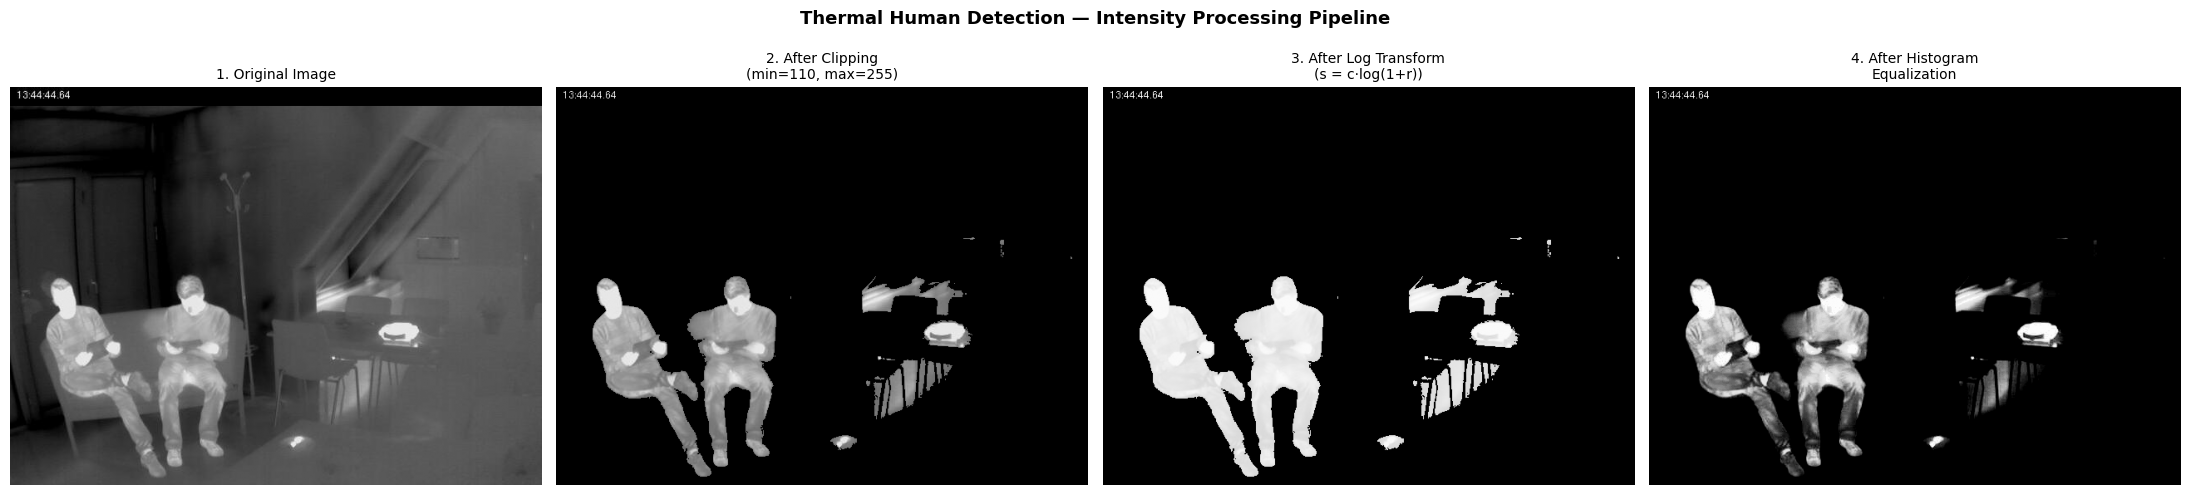

Figure saved as pipeline_output.png


In [7]:
# ── Visualization: 1×4 comparison grid ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Thermal Human Detection — Intensity Processing Pipeline',
             fontsize=13, fontweight='bold', y=1.02)

stages = [
    (original_img,  '1. Original Image'),
    (clipped_img,   f'2. After Clipping\n(min={CLIP_MIN}, max={CLIP_MAX})'),
    (log_img,       '3. After Log Transform\n(s = c·log(1+r))'),
    (equalized_img, '4. After Histogram\nEqualization'),
]

for ax, (img, title) in zip(axes, stages):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('pipeline_output.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as pipeline_output.png")